# Hands-on #8. Annealing Softmax Bandit

# Annealing

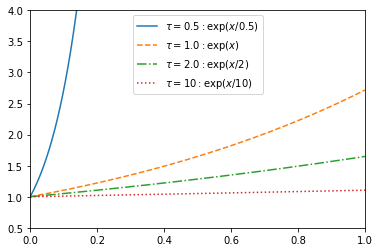

In [37]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

x = np.arange(0, 1.001, 0.001)

e_0_5 = np.exp(x/0.1)
e_1 = np.exp(x/1.0)
e_2 = np.exp(x/2.)
e_10 = np.exp(x/10.0)


plt.plot(x, e_0_5, '-', label=r"$\tau=0.5: \exp(x/0.5)$")
plt.plot(x, e_1, '--', label=r"$\tau=1.0: \exp(x)$")
plt.plot(x, e_2, '-.', label=r"$\tau=2.0: \exp(x/2)$")
plt.plot(x, e_10, ':', label=r"$\tau=10: \exp(x/10)$")


plt.legend()
plt.xlim([0, 1])
plt.ylim([0.5, 4])
plt.show()


# Annealing Softmax Agent

In [28]:
class Env(object):
    n_arms = 4
    thetas = [0.1, 0.1, 0.2, 0.3]

    @staticmethod
    def react(arm):
        return 1 if np.random.random() < Env.thetas[arm] else 0

    @staticmethod
    def opt():
        return np.argmax(Env.thetas)

print(f"Num. arms: {Env.n_arms}")
print(f"Thetas: {Env.thetas}")
print(f"Try the arm 1: {Env.react(1)}")

Num. arms: 4
Thetas: [0.1, 0.1, 0.2, 0.3]
Try the arm 1: 0


In [29]:
# I have copied the SoftmaxAgent from the lecture note.
# Make two changes to parts of the code that are marked as TODO.

class AnnealingSoftmaxAgent(object):
    def __init__(self, tau=0.05): # TODO. Change the initial temperature to encourage the agent to explore
        self.tau = tau
        self.counts = np.zeros(Env.n_arms)
        self.values = np.zeros(Env.n_arms)

    def softmax_p(self):
        logit = self.values / self.tau
        logit = logit - np.max(logit)
        p = np.exp(logit) / sum(np.exp(logit))
        return p

    def get_arm(self):
        arm = np.random.choice(Env.n_arms, p=self.softmax_p())

        # TODO. Edit this part so that the temperature decreases over time.

        return arm

    def sample(self, arm, reward):
        self.counts[arm] = self.counts[arm] + 1
        self.values[arm] = ((self.counts[arm] - 1) * self.values[arm] + reward) / self.counts[arm]

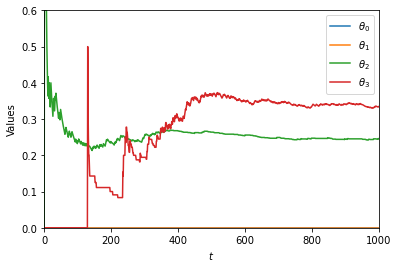

In [30]:
agent = AnnealingSoftmaxAgent()
budget = 1000

value_snapshots = np.zeros((1000, 4))
rewards = np.zeros(1000)

for t in range(budget):
    arm = agent.get_arm()
    reward = Env.react(arm)
    agent.sample(arm, reward)

    rewards[t] = reward
    value_snapshots[t, :] = agent.values.copy()

plt.plot(value_snapshots[:, 0], label=r'$\theta_0$')
plt.plot(value_snapshots[:, 1], label=r'$\theta_1$')
plt.plot(value_snapshots[:, 2], label=r'$\theta_2$')
plt.plot(value_snapshots[:, 3], label=r'$\theta_3$')

plt.xlim([0, 1000])
plt.ylim([0, 0.6])

plt.xlabel(r"$t$")
plt.ylabel("Values")
plt.legend()
plt.show()